# Predicción de la edad de zarigüeyas

[https://www.kaggle.com/datasets/abrambeyer/openintro-possum](https://www.kaggle.com/datasets/abrambeyer/openintro-possum)

### ¿Qué dimensiones corporales de las zarigüeyas están más correlacionadas con la edad y el sexo?


La edad tiene una correlación entre el 0.3 y 0.4 con el chest y el belly. Las medidas longitudinales se estabilizan al llegar a la adultez, por lo que su correlación con la edad no es tan notable.

### ¿Podemos predecir el lugar de captura de una zarigüeya a partir de las dimensiones de su cuerpo?

Sí, ya que el dataset incluye las variables site y Pop, y las zarigüeyas variaciones morfológicas dependiendo de su hábitat.

### Predecir la edad de una zarigüeya a partir del resto de los datos.

A continuación

---

### Librerías necesarias

In [1]:
%pip install kagglehub[pandas-datasets]


   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------- ----------------------------- 1/4 [protobuf]
   ---------- ----------------------------- 1/4 [protobuf]
   ---------- ----------------------------- 1/4 [protobuf]
   ---------- ----------------------------- 1/4 [protobuf]
   ---------- ----------------------------- 1/4 [protobuf]
   ---------- ----------------------------- 1/4 [protobuf]
   -------------------- ------------------- 2/4 [kagglesdk]
   -------------------- ------------------- 2/4 [kagglesdk]
   -------------------- ------------------- 2/4 [kagglesdk]
   -------------------- ------------------- 2/4 [kagglesdk]
   -------------------- ------------------- 2/4 [kagglesdk]
   -------------------- ------------------- 2/4 [kagglesdk]
   -------------------- ------------------- 2/4 [kagglesdk]
   -------------------- ------------------- 2/4 [kagglesdk]


In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestRegressor

### Importar el DataSet

In [2]:
file_path = "possum.csv"
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "abrambeyer/openintro-possum",
  file_path,
)

df.head(12)

C:\Users\eloy.garciamartinez\AppData\Local\Temp\ipykernel_14688\1500016256.py:2: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0
5,6,1,Vic,f,1.0,93.1,54.8,90.5,35.5,73.2,53.6,14.2,30.0,32.0
6,7,1,Vic,m,2.0,95.3,58.2,89.5,36.0,71.5,52.0,14.2,30.0,34.5
7,8,1,Vic,f,6.0,94.8,57.6,91.0,37.0,72.7,53.9,14.5,29.0,34.0
8,9,1,Vic,f,9.0,93.4,56.3,91.5,37.0,72.4,52.9,15.5,28.0,33.0
9,10,1,Vic,f,6.0,91.8,58.0,89.5,37.5,70.9,53.4,14.4,27.5,32.0


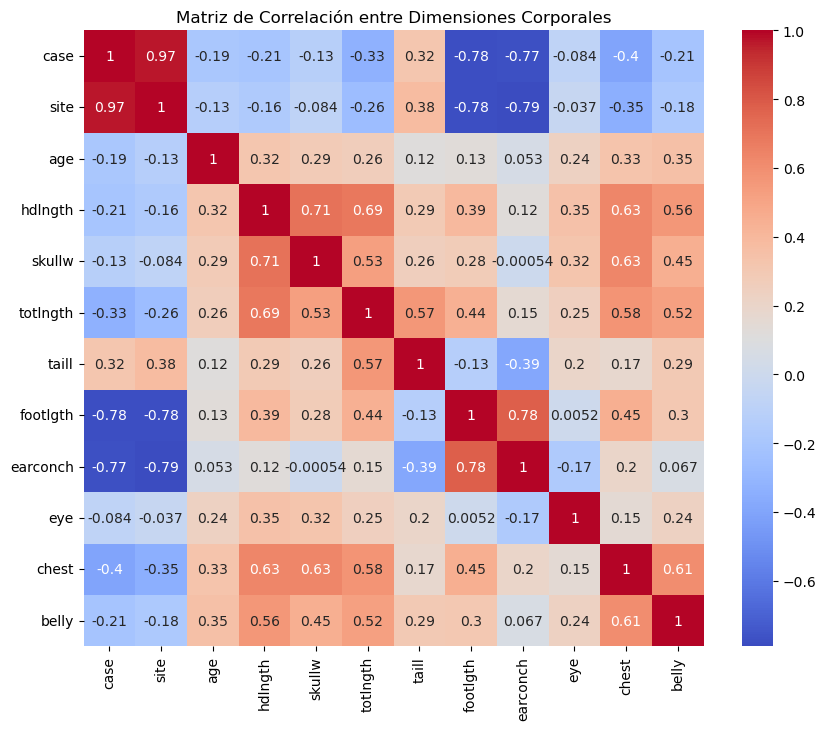

In [3]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación entre Dimensiones Corporales')
plt.show()

### Preprocesado de los datos

In [4]:
X = df.drop('age', axis=1)
y = df['age']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(83, 13) (21, 13) (83,) (21,)


In [5]:
# Eliminar variables redundantes (case y site), estan muy correlacionadas
X_train = X_train.drop(['case', 'site'], axis=1, errors='ignore')
X_test = X_test.drop(['case', 'site'], axis=1, errors='ignore')
y_train = y_train.dropna()
X_train = X_train.loc[y_train.index]
y_test = y_test.dropna()
X_test = X_test.loc[y_test.index]

# Actualizar columnas categóricas y numéricas
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

#creamos preprocessor con pipelines porque el df es mixto
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder())
        ]), categorical_cols),
        
        #para númericas
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())  #los números tendrán media 0 y desv. típica 1, esto no es necesario para arboles de decision que son inmunes a escalados, no les importa la medida de los datos
    ]), numeric_cols)
    ])

### Entrenamos el modelo

In [6]:
#creamos el bosque aleatorio con 100 arboles diferentes y un random state para que el resultado sea reproducible
model = Pipeline([
    ('prep', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

model.fit(X_train, y_train)

,steps,"[('prep', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Tuning de hiperparametros

In [7]:
param_grid = {  #preceder de regressor__ para indicarle a que paso del pipeline pertenecen los parametros
    'regressor__n_estimators': [50, 100, 200, 300],  #mas arboles != sobreajuste, como el dataset es pequeño probamos con mas arboles
    'regressor__max_depth': [2, 3, 4, 5],  #una profundidad de 6 o mas ya podria provocar que el arbol separa cada dato por hoja
    'regressor__min_samples_split': [5, 10, 15],  #division de al menos 5 datos por hoja para frenar la ramificación innecesaria en mas hojas
    'regressor__min_samples_leaf': [2, 4, 6], #minimo 2% de datos par ahacer prediccion en hoja final y evitar coger outliers
    'regressor__max_features': ['sqrt', 'log2', 1.0]
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'regressor__max_depth': [2, 3, ...], 'regressor__max_features': ['sqrt', 'log2', ...], 'regressor__min_samples_leaf': [2, 4, ...], 'regressor__min_samples_split': [5, 10, ...], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cat', ...), ('num', ...)]"


### Predicciones

In [8]:
#grid_search.predict usa automáticamente el "best_estimator_"
y_pred = grid_search.predict(X_test)

#.score usa la métrica default del estimador, r^2 para todos los regresores 
score = grid_search.score(X_test, y_test)
print(score)

0.19530853395381897


### Conclusiones y visualización de resultados

In [9]:
df_test_con_ypred = df.loc[X_test.index].copy()
#aadimos la columna de las predicciones en el df
df_test_con_ypred['edad_predicha'] = y_pred

df_test_con_ypred.sort_values(by='age' ,ascending=False).head(50)

,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly,edad_predicha
10,11,1,Vic,f,9.0,93.3,57.2,89.5,39.0,77.2,51.3,14.9,31.0,34.0,4.319886
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0,4.579081
53,54,4,other,m,7.0,96.9,63.0,91.5,43.0,71.3,46.0,17.5,30.0,36.5,3.606180
93,94,7,other,m,7.0,91.8,57.6,84.0,35.5,64.2,45.1,14.4,29.0,35.0,4.316682
88,89,7,other,m,6.0,97.7,58.4,84.5,35.0,64.4,46.2,14.4,29.0,30.5,3.965561
64,65,5,other,f,5.0,93.5,57.4,88.5,38.0,68.2,41.7,14.0,29.0,38.5,4.335576
12,13,1,Vic,m,5.0,95.1,59.9,89.5,36.0,71.0,49.8,15.8,27.0,32.0,4.208060
47,48,3,other,m,5.0,98.6,63.2,85.0,34.0,66.9,44.9,17.0,28.0,35.0,4.139152
18,19,1,Vic,f,5.0,94.4,55.4,90.5,35.0,73.4,53.9,15.2,28.0,32.0,3.649442
31,32,1,Vic,f,4.0,94.3,56.7,94.0,39.0,74.8,52.0,14.9,28.0,34.0,4.696562
